# 📘 Module 2: Deep Learning Fundamentals with PyTorch
## From a Single Neuron → Multi-Layer Network → Beating Module 1 Models

---

> **Series:** Fine-Tuning & ML Fundamentals — From Zero to Enterprise  
> **Module:** 2 of 6  
> **Prerequisites:** Module 1 (Traditional ML)  
> **Level:** Beginner → Intermediate  
> **Time to complete:** ~3 hours

---

## 👋 What This Module Builds On

In **Module 1** you learned:
- Supervised learning, the 7-step workflow
- Logistic Regression, Decision Tree, Random Forest
- EDA, preprocessing, evaluation metrics

**This module answers the question:** Why do we need neural networks at all if Random Forest already works well?

The answer has two parts:
1. For structured/tabular data (like churn), Random Forest is often *good enough* — and that's fine
2. For **images, text, audio, video** — traditional ML completely fails. Neural networks are the only approach

GPT, Claude, Stable Diffusion, speech recognition — **all neural networks, all PyTorch under the hood.**

---

## 🗺️ What You Will Learn

| Topic | What It Means |
|---|---|
| What is a Neuron? | The smallest building block — explained from biology |
| Build a neuron from scratch | Pure NumPy, zero libraries, full understanding |
| Activation Functions | Why non-linearity is the secret ingredient |
| Forward Pass | How data flows through a network |
| Loss Functions | How the model measures its own mistakes |
| Backpropagation | How the model learns from mistakes |
| Gradient Descent | The optimizer that adjusts the weights |
| PyTorch | Build the same thing faster with less code |
| Training Loop | The engine of all deep learning |
| Regularization | Dropout & BatchNorm to prevent overfitting |
| Learning Curves | How to diagnose what's wrong with training |
| Final Comparison | NN vs RF vs LR — who wins? |

---

## ⚙️ Setup

In [1]:
# Install if needed:
# !pip install torch pandas numpy scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    roc_curve, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print(f'PyTorch version : {torch.__version__}')
print(f'NumPy   version : {np.__version__}')
print(f'pandas  version : {pd.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {device} (GPU available: {torch.cuda.is_available()})')
print('✅ All libraries loaded!')

PyTorch version : 1.13.1+cpu
NumPy   version : 1.26.4
pandas  version : 3.0.3
Device          : cpu (GPU available: False)
✅ All libraries loaded!


---

# 📖 LESSON 1: What Is a Neural Network?

## The Biology → Math Translation

Your brain has ~86 billion neurons. Each neuron:
1. **Receives signals** from other neurons through dendrites
2. **Adds them up** — if the total is strong enough...
3. **Fires** — sends a signal forward to the next neurons

An **artificial neuron** works exactly the same way:
1. **Receives inputs** (e.g., tenure=12, monthly_charges=95)
2. **Multiplies each by a weight** and adds a bias: `z = w1*x1 + w2*x2 + ... + b`
3. **Passes through activation function** — fires or stays quiet: `output = activation(z)`

```
                   Inputs      Weights
  tenure=12   ────── ×0.3 ──┐
  charges=95  ────── ×0.7 ──┼──► SUM ──► Activation ──► Output (0.82)
  calls=5     ────── ×0.2 ──┘      + bias
```

## Why Do We Need Many Neurons?

One neuron = one linear boundary (like Logistic Regression).  
Stack many neurons in **layers** → the network can learn curved, complex, non-linear patterns.

This is the **Universal Approximation Theorem**: a neural network with enough neurons can approximate *any* function. It can learn any pattern in data, no matter how complex.

---

## Network Anatomy

```
INPUT LAYER     HIDDEN LAYER 1   HIDDEN LAYER 2   OUTPUT LAYER
                                                      
 tenure  ───┐                                         
 charges ───┼──► [Neuron]──┐                         
 calls   ───┤   [Neuron]──┼──► [Neuron]──┐          
 age     ───┤   [Neuron]──┤   [Neuron]──┼──► [Churn Prob]
 ...     ───┘   [Neuron]──┘   [Neuron]──┘          
                                                      
 (15 features)  (64 neurons)   (32 neurons)   (1 output)
```

- **Input layer**: one node per feature (no computation, just passes data in)
- **Hidden layers**: where the actual learning happens
- **Output layer**: one node for binary classification (churn probability)

---

# 🔧 LESSON 2: Build a Neuron From Scratch (No PyTorch)

Before using any library, let's build everything manually. This is the best way to truly understand what's happening inside the black box.

In [2]:
# ── A Single Artificial Neuron ──────────────────────────────────────
# This is the smallest unit of every neural network.
# It takes inputs, multiplies by weights, adds a bias, applies activation.

class SingleNeuron:
    def __init__(self, n_inputs):
        # Weights start random (small values near 0)
        # Each input gets its own weight
        self.weights = np.random.randn(n_inputs) * 0.1
        self.bias    = 0.0
    
    def sigmoid(self, z):
        """Sigmoid squashes any number into [0, 1] — perfect for probability"""
        return 1 / (1 + np.exp(-z))
    
    def forward(self, x):
        """Forward pass: compute the output for an input"""
        z = np.dot(x, self.weights) + self.bias   # weighted sum
        return self.sigmoid(z)                     # activation

# Demo: one neuron with 3 inputs
neuron = SingleNeuron(n_inputs=3)
sample_input = np.array([0.5, -1.2, 0.8])  # 3 features
output = neuron.forward(sample_input)

print('=== Single Neuron Demo ===')
print(f'Input:   {sample_input}')
print(f'Weights: {neuron.weights.round(4)}')
print(f'Bias:    {neuron.bias}')
z = np.dot(sample_input, neuron.weights) + neuron.bias
print(f'z (weighted sum): {z:.4f}')
print(f'Output (sigmoid): {output:.4f}  →  {output*100:.1f}% probability')
print()
print('This single neuron just predicted: churn probability =', f'{output:.1%}')
print('But the weights are random, so this prediction is meaningless yet.')
print('LEARNING = adjusting the weights until predictions are correct.')

=== Single Neuron Demo ===
Input:   [ 0.5 -1.2  0.8]
Weights: [ 0.0497 -0.0138  0.0648]
Bias:    0.0
z (weighted sum): 0.0932
Output (sigmoid): 0.5233  →  52.3% probability

This single neuron just predicted: churn probability = 52.3%
But the weights are random, so this prediction is meaningless yet.
LEARNING = adjusting the weights until predictions are correct.


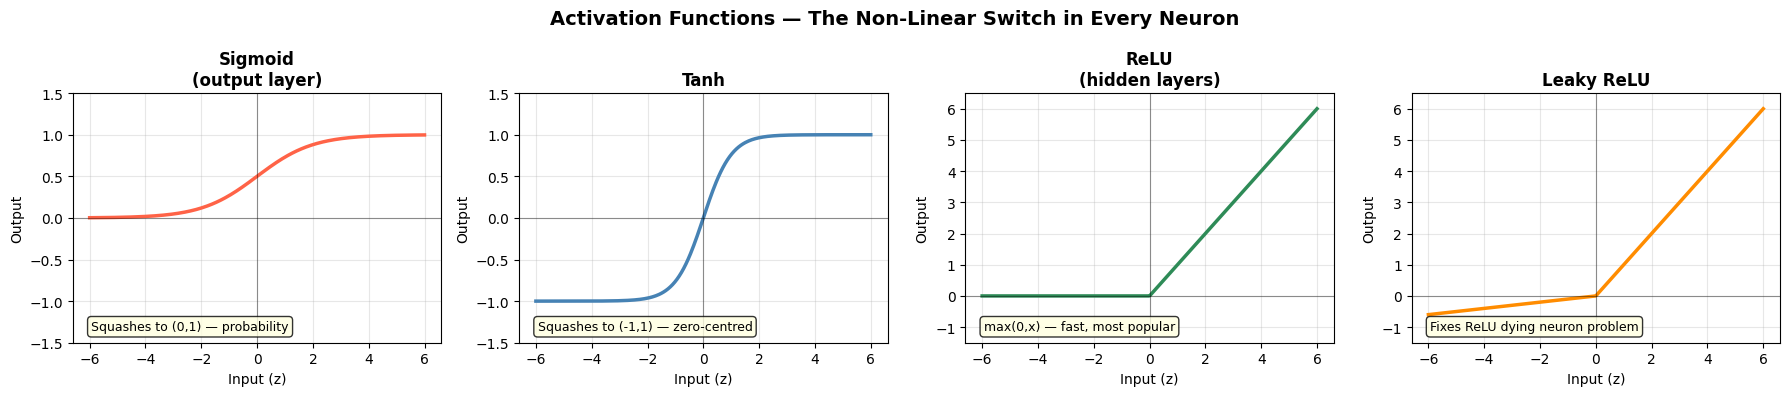

💡 Rule of thumb:
   Hidden layers → use ReLU (fast, rarely saturates)
   Output layer (binary classification) → use Sigmoid (gives 0-1 probability)
   Output layer (multi-class) → use Softmax (probabilities that sum to 1)


In [3]:
# ── Visualize Activation Functions ──────────────────────────────────
# Activation functions are the non-linear "switches" that make deep learning powerful
# Without them, stacking layers is useless (multiple linear layers = one linear layer)

x = np.linspace(-6, 6, 300)

activations = {
    'Sigmoid\n(output layer)':  (1 / (1 + np.exp(-x)),      'tomato',    'Squashes to (0,1) — probability'),
    'Tanh':                     (np.tanh(x),                 'steelblue', 'Squashes to (-1,1) — zero-centred'),
    'ReLU\n(hidden layers)':    (np.maximum(0, x),           'seagreen',  'max(0,x) — fast, most popular'),
    'Leaky ReLU':               (np.where(x > 0, x, 0.1*x), 'darkorange','Fixes ReLU dying neuron problem'),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, (y, color, desc)) in zip(axes, activations.items()):
    ax.plot(x, y, color=color, lw=2.5)
    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.axvline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Input (z)')
    ax.set_ylabel('Output')
    ax.set_ylim(-1.5, 1.5 if 'ReLU' not in name else 6.5)
    ax.grid(alpha=0.3)
    ax.text(0.05, 0.05, desc, transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Activation Functions — The Non-Linear Switch in Every Neuron',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Rule of thumb:')
print('   Hidden layers → use ReLU (fast, rarely saturates)')
print('   Output layer (binary classification) → use Sigmoid (gives 0-1 probability)')
print('   Output layer (multi-class) → use Softmax (probabilities that sum to 1)')

### 📝 Why Activation Functions Are the Key Ingredient

Without an activation function, a neural network — no matter how deep — is just doing **one linear transformation**. You could replace 10 linear layers with a single matrix multiplication and get the same result.

Activation functions introduce **non-linearity**. This is what allows a network to learn curves, spirals, complex boundaries — any shape.

```
No activation:    output = W3 × (W2 × (W1 × input))  =  W_total × input  (still linear!)
With ReLU:        output = W3 × ReLU(W2 × ReLU(W1 × input))  (truly non-linear)
```

**Why ReLU is the default for hidden layers:**
- Sigmoid and Tanh "saturate" (output stays flat at extremes) → gradients become near-zero → network stops learning (called the **vanishing gradient problem**)
- ReLU has a constant gradient of 1 for positive inputs → no vanishing
- ReLU is also just `max(0, x)` — extremely fast to compute

---

# 📖 LESSON 3: How a Network Actually Learns

## The 4-Step Learning Loop

```
┌──────────────────────────────────────────────────────────────────┐
│  STEP 1: FORWARD PASS                                            │
│  Feed data through the network → get a prediction               │
│                                                                  │
│  STEP 2: COMPUTE LOSS                                            │
│  Compare prediction to actual label → measure the mistake       │
│                                                                  │
│  STEP 3: BACKWARD PASS (Backpropagation)                        │
│  Calculate how much each weight contributed to the mistake      │
│  (using the chain rule of calculus — PyTorch does this for you) │
│                                                                  │
│  STEP 4: UPDATE WEIGHTS (Gradient Descent)                      │
│  Nudge each weight in the direction that reduces the loss       │
│  weight = weight - learning_rate × gradient                     │
│                                                                  │
│  Repeat thousands of times → weights converge → model learns    │
└──────────────────────────────────────────────────────────────────┘
```

## Key Terms

| Term | Meaning |
|---|---|
| **Loss / Cost** | How wrong the model is — we want to minimise this |
| **Gradient** | Direction and magnitude to adjust each weight |
| **Learning Rate** | How big each weight adjustment step is |
| **Epoch** | One full pass through the entire training dataset |
| **Batch** | A small chunk of training data processed at once |
| **Iteration** | One weight update (one batch processed) |
| **Backpropagation** | Computing gradients via chain rule — the engine of learning |

## Gradient Descent — The Core Intuition

Imagine you're blindfolded on a hilly landscape and want to find the lowest valley (minimum loss).  
You feel the slope under your feet (gradient) and take a step downhill. Repeat until you reach the bottom.

- **Too large a learning rate**: you overshoot, bouncing around, never settling
- **Too small a learning rate**: you move so slowly it takes forever
- **Just right**: smooth convergence to the minimum

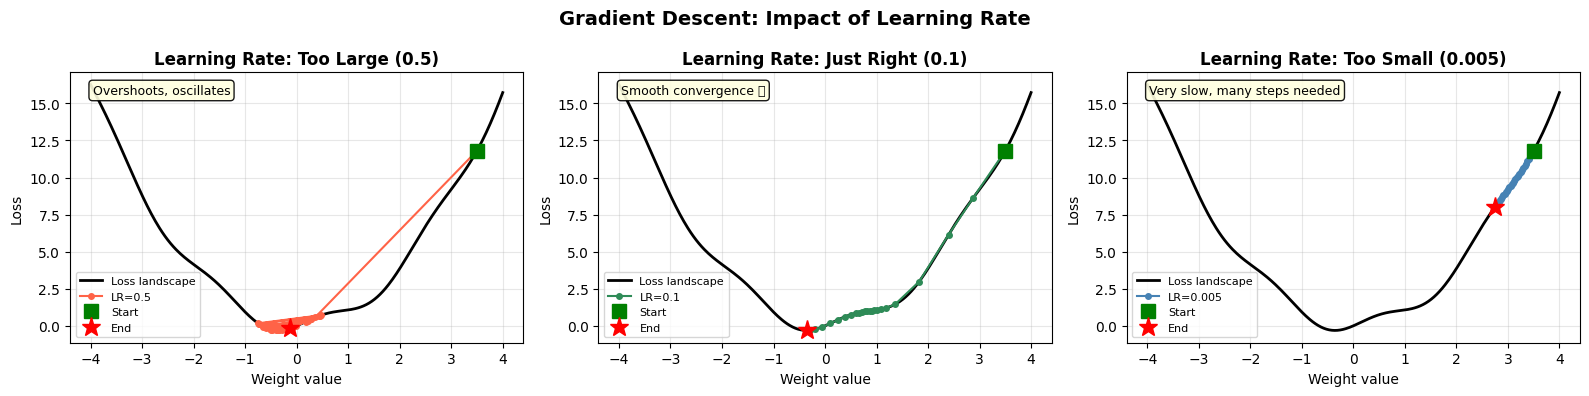

💡 The default learning rate for Adam optimizer is 0.001 — a reliable starting point.


In [4]:
# ── Visualise Gradient Descent ───────────────────────────────────────
# Show how 3 different learning rates behave on a simple loss curve

x_gd = np.linspace(-4, 4, 300)
loss_fn = lambda w: w**2 + 0.5 * np.sin(3*w)   # bumpy bowl shape

def gradient_descent_path(start, lr, steps=20):
    w = start
    path = [w]
    for _ in range(steps):
        grad = 2*w + 1.5*np.cos(3*w)   # derivative of loss_fn
        w = w - lr * grad
        path.append(w)
    return path

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    (0.5,  'Too Large (0.5)',  'tomato',    'Overshoots, oscillates'),
    (0.1,  'Just Right (0.1)', 'seagreen',  'Smooth convergence ✅'),
    (0.005,'Too Small (0.005)', 'steelblue', 'Very slow, many steps needed'),
]

for ax, (lr, title, color, note) in zip(axes, configs):
    path = gradient_descent_path(start=3.5, lr=lr, steps=30)
    ax.plot(x_gd, [loss_fn(w) for w in x_gd], 'k-', lw=2, label='Loss landscape')
    ax.plot([p for p in path], [loss_fn(p) for p in path],
            'o-', color=color, markersize=4, lw=1.5, label=f'LR={lr}')
    ax.plot(path[0], loss_fn(path[0]), 'gs', markersize=10, label='Start', zorder=5)
    ax.plot(path[-1], loss_fn(path[-1]), 'r*', markersize=14, label='End', zorder=5)
    ax.set_title(f'Learning Rate: {title}', fontweight='bold')
    ax.set_xlabel('Weight value')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.text(0.05, 0.92, note, transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('Gradient Descent: Impact of Learning Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradient_descent.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 The default learning rate for Adam optimizer is 0.001 — a reliable starting point.')

---

# 📦 STEP 1: Prepare the Same Churn Dataset

We use the exact same data as Module 1. This is intentional — so you can directly compare neural network performance against Random Forest.

In [5]:
# ── Recreate Module 1 dataset (same seed = same data) ────────────────
np.random.seed(42)
n = 5000

tenure       = np.random.randint(1, 72, size=n)
monthly      = np.random.uniform(20, 120, size=n)
age          = np.random.randint(18, 75, size=n)
support_calls= np.random.poisson(lam=2, size=n)
outages      = np.random.poisson(lam=1, size=n)
contract     = np.random.choice(['Month-to-Month','One-Year','Two-Year'], size=n, p=[0.55,0.25,0.20])
payment      = np.random.choice(['Electronic Check','Mailed Check','Bank Transfer','Credit Card'], size=n, p=[0.35,0.25,0.20,0.20])
has_streaming= np.random.choice([0,1], size=n, p=[0.45,0.55])
has_security = np.random.choice([0,1], size=n, p=[0.60,0.40])

churn_prob = np.clip(
    0.10 + 0.30*(contract=='Month-to-Month') - 0.15*(contract=='Two-Year')
    + 0.005*support_calls + 0.05*outages - 0.003*tenure
    + 0.002*monthly - 0.05*has_security + 0.10*(payment=='Electronic Check'),
    0.02, 0.95
)
churn = (np.random.rand(n) < churn_prob).astype(int)
total_charges = tenure * monthly * np.random.uniform(0.95, 1.05, size=n)

df = pd.DataFrame({
    'customer_id': [f'CUST_{i:05d}' for i in range(n)],
    'tenure_months': tenure, 'monthly_charges': monthly.round(2),
    'total_charges': total_charges.round(2), 'num_support_calls': support_calls,
    'num_service_outages': outages, 'age': age,
    'contract_type': contract, 'payment_method': payment,
    'has_streaming': has_streaming, 'has_security_addon': has_security, 'churn': churn
})

# Preprocess exactly as Module 1
df_ml      = df.drop(columns=['customer_id'])
df_encoded = pd.get_dummies(df_ml, columns=['contract_type','payment_method'], drop_first=False)

X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Dataset: {n} customers, {X.shape[1]} features')
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Churn rate: {y.mean()*100:.1f}%')
print(f'Features: {list(X.columns)}')

Dataset: 5000 customers, 15 features
Train: 4000 rows | Test: 1000 rows
Churn rate: 35.1%
Features: ['tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'num_service_outages', 'age', 'has_streaming', 'has_security_addon', 'contract_type_Month-to-Month', 'contract_type_One-Year', 'contract_type_Two-Year', 'payment_method_Bank Transfer', 'payment_method_Credit Card', 'payment_method_Electronic Check', 'payment_method_Mailed Check']


---

# 🔥 STEP 2: Introduce PyTorch

## What Is PyTorch?

PyTorch is the library used to build neural networks. It handles:
- **Tensors**: like NumPy arrays, but GPU-compatible
- **Autograd**: automatic computation of gradients (backpropagation for free)
- **nn.Module**: building blocks for layers, models
- **Optimizers**: Adam, SGD — weight update algorithms

### PyTorch vs TensorFlow
Both do the same thing. PyTorch is now the dominant framework in research and increasingly in production. All major LLMs (GPT, Claude, LLaMA) are trained with PyTorch.

In [6]:
# ── PyTorch Tensors — 5 Minute Crash Course ──────────────────────────
# A Tensor is just a multi-dimensional array (like NumPy ndarray)
# The difference: tensors can run on GPU and track gradients automatically

# Create tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print('=== Tensor Basics ===')
print(f'a = {a}')
print(f'b = {b}')
print(f'a + b = {a + b}')
print(f'a * b = {a * b}')
print(f'dot(a,b) = {torch.dot(a, b)}')
print(f'Shape: {a.shape}, dtype: {a.dtype}')
print()

# From NumPy ↔ Tensor (no data copy if on CPU)
np_array = np.array([1.0, 2.0, 3.0])
tensor_from_np = torch.from_numpy(np_array)
back_to_np     = tensor_from_np.numpy()
print(f'NumPy → Tensor: {tensor_from_np}')
print(f'Tensor → NumPy: {back_to_np}')
print()

# Autograd: PyTorch tracks operations to compute gradients automatically
# This is what makes backpropagation happen without you writing the math
w = torch.tensor(2.0, requires_grad=True)   # this is a model weight
x_val = torch.tensor(3.0)                   # this is an input
loss_val = (w * x_val - 5.0) ** 2           # MSE-style loss
loss_val.backward()                          # compute gradient automatically
print(f'w = {w.item()}, x = {x_val.item()}')
print(f'loss = (w*x - 5)^2 = {loss_val.item():.4f}')
print(f'gradient d(loss)/dw = {w.grad.item():.4f}')
print(f'Manual check: 2*(w*x - 5)*x = 2*({w.item()*x_val.item()} - 5)*{x_val.item()} = {2*(w.item()*x_val.item()-5)*x_val.item():.4f}')
print('✅ PyTorch computed the exact derivative for us!')

=== Tensor Basics ===
a = tensor([1., 2., 3.])
b = tensor([4., 5., 6.])
a + b = tensor([5., 7., 9.])
a * b = tensor([ 4., 10., 18.])
dot(a,b) = 32.0
Shape: torch.Size([3]), dtype: torch.float32

NumPy → Tensor: tensor([1., 2., 3.], dtype=torch.float64)
Tensor → NumPy: [1. 2. 3.]

w = 2.0, x = 3.0
loss = (w*x - 5)^2 = 1.0000
gradient d(loss)/dw = 6.0000
Manual check: 2*(w*x - 5)*x = 2*(6.0 - 5)*3.0 = 6.0000
✅ PyTorch computed the exact derivative for us!


In [7]:
# ── Convert our churn data to PyTorch Tensors ─────────────────────────

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)  # shape: (N, 1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

# DataLoader: feeds data in mini-batches during training
# Batch size = how many samples to process before updating weights
# 64 is a common default — large enough to be stable, small enough to be fast
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'X_train tensor shape: {X_train_t.shape}  (4000 samples × {X_train_t.shape[1]} features)')
print(f'y_train tensor shape: {y_train_t.shape}  (4000 labels × 1)')
print(f'Number of batches per epoch: {len(train_loader)}')
print(f'Each batch has {BATCH_SIZE} samples')
print()
print('Why batches?')
print('  - Full dataset at once: uses too much memory, slow')
print('  - One sample at once: very noisy updates, slow to converge')
print('  - Mini-batches (32-256): best of both worlds ✅')

X_train tensor shape: torch.Size([4000, 15])  (4000 samples × 15 features)
y_train tensor shape: torch.Size([4000, 1])  (4000 labels × 1)
Number of batches per epoch: 63
Each batch has 64 samples

Why batches?
  - Full dataset at once: uses too much memory, slow
  - One sample at once: very noisy updates, slow to converge
  - Mini-batches (32-256): best of both worlds ✅


---

# 🏗️ STEP 3: Build the Neural Network

## Architecture Design Decisions

| Decision | Our Choice | Why |
|---|---|---|
| Input size | 15 (# features) | Fixed by data |
| Hidden layer 1 | 64 neurons | Rule of thumb: start 2-4× input size |
| Hidden layer 2 | 32 neurons | Funnel shape — compress to essence |
| Hidden layer 3 | 16 neurons | Deeper = more capacity for complex patterns |
| Output size | 1 | Binary classification (churn probability) |
| Activation | ReLU (hidden), Sigmoid (output) | Standard for tabular classification |
| Dropout | 30% | Regularization to prevent overfitting |
| BatchNorm | Yes | Stabilizes training, allows higher learning rate |

In [8]:
# ── Define the Neural Network Architecture ───────────────────────────
# In PyTorch, every model is a class that inherits from nn.Module
# You define: what layers exist (__init__) and how data flows (forward)

class ChurnNet(nn.Module):
    def __init__(self, input_size, dropout_rate=0.3):
        super(ChurnNet, self).__init__()
        
        # nn.Sequential chains layers left to right
        self.network = nn.Sequential(
            # ── Layer 1: 15 inputs → 64 neurons ──
            nn.Linear(input_size, 64),  # Linear = fully connected layer
            nn.BatchNorm1d(64),          # Normalize activations → stable training
            nn.ReLU(),                   # Non-linear activation
            nn.Dropout(dropout_rate),    # Randomly zero out 30% of neurons → prevents memorisation
            
            # ── Layer 2: 64 → 32 neurons ──
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # ── Layer 3: 32 → 16 neurons ──
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # ── Output: 16 → 1 (churn probability) ──
            nn.Linear(16, 1),
            nn.Sigmoid()   # squash to [0,1] probability
        )
    
    def forward(self, x):
        """Forward pass: how data flows from input to output"""
        return self.network(x)

# Instantiate the model
input_size = X_train_t.shape[1]
model = ChurnNet(input_size=input_size, dropout_rate=0.3)
model = model.to(device)

# Print the model architecture
print('=== ChurnNet Architecture ===')
print(model)
print()

# Count total learnable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'(Each parameter is a weight or bias that gets updated during training)')

=== ChurnNet Architecture ===
ChurnNet(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Total parameters:     3,841
Trainable parameters: 3,841
(Each parameter is a weight or bias that gets updated during training)


### 📝 Understanding Dropout and BatchNorm

**Dropout (regularization technique)**  
During training, randomly "turns off" a fraction of neurons each batch. This forces the network to learn redundant paths — it can't rely on any single neuron. Like training a sports team where random players sit out each practice — every player has to be capable.

- During **training**: neurons randomly dropped
- During **inference** (prediction): all neurons active (scaled by dropout rate)
- Common values: 0.2 – 0.5

**Batch Normalisation**  
Normalises the output of each layer so it has mean≈0 and std≈1. Benefits:
- Allows higher learning rates → faster training
- Reduces sensitivity to weight initialisation
- Acts as mild regularization

Loss function: Binary Cross-Entropy (BCELoss)
Optimizer:     Adam (lr=0.001)
Scheduler:     ReduceLROnPlateau (halves LR after 5 epochs with no improvement)



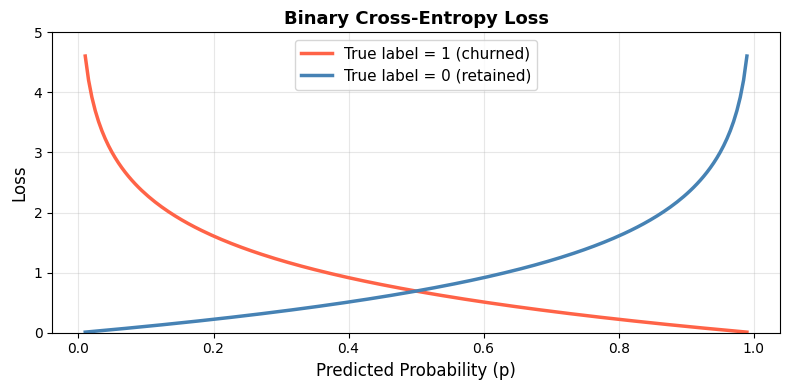

Read: If the true label is 1 (churned) and we predict p=0.9 → low loss (good!)
      If the true label is 1 (churned) and we predict p=0.1 → HIGH loss (bad!)


In [9]:
# ── Set up Loss Function and Optimizer ───────────────────────────────

# Binary Cross-Entropy Loss:
# For a prediction p and true label y:
# loss = -[y * log(p) + (1-y) * log(1-p)]
# → When prediction is correct and confident: loss is near 0
# → When prediction is wrong and confident:   loss is very high
criterion = nn.BCELoss()

# Adam Optimizer: an improved gradient descent
# It adapts the learning rate per-parameter and uses momentum
# lr=0.001 is a reliable default for Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler: reduce LR if validation loss stops improving
# This is like slowing down when you're near the bottom of the valley
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, verbose=False
)

print('Loss function: Binary Cross-Entropy (BCELoss)')
print('Optimizer:     Adam (lr=0.001)')
print('Scheduler:     ReduceLROnPlateau (halves LR after 5 epochs with no improvement)')
print()

# Demo: what does BCE loss look like?
p_vals = np.linspace(0.01, 0.99, 200)
bce_true1  = -np.log(p_vals)        # true label=1: penalise low predictions
bce_true0  = -np.log(1 - p_vals)    # true label=0: penalise high predictions

plt.figure(figsize=(8, 4))
plt.plot(p_vals, bce_true1, 'tomato', lw=2.5, label='True label = 1 (churned)')
plt.plot(p_vals, bce_true0, 'steelblue', lw=2.5, label='True label = 0 (retained)')
plt.xlabel('Predicted Probability (p)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Binary Cross-Entropy Loss', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('bce_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print('Read: If the true label is 1 (churned) and we predict p=0.9 → low loss (good!)')
print('      If the true label is 1 (churned) and we predict p=0.1 → HIGH loss (bad!)')

---

# 🏋️ STEP 4: The Training Loop

This is the heart of all deep learning. Every framework, every model, every paper uses this same loop.

In [10]:
# ── The Training Loop ────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer):
    """Train for one epoch: iterate over all batches, update weights."""
    model.train()   # important: activates Dropout and BatchNorm training behaviour
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Step 1: Forward pass — get predictions
        predictions = model(X_batch)
        
        # Step 2: Compute loss — how wrong are we?
        loss = criterion(predictions, y_batch)
        
        # Step 3: Backward pass — compute gradients
        optimizer.zero_grad()   # always clear old gradients first!
        loss.backward()         # PyTorch computes all gradients automatically
        
        # Step 4: Update weights
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    """Evaluate on validation/test set. No weight updates."""
    model.eval()    # disables Dropout, uses full network
    total_loss, all_preds, all_probs, all_labels = 0, [], [], []
    
    with torch.no_grad():   # no gradients needed — saves memory and is faster
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            loss  = criterion(probs, y_batch)
            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy().flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())
            all_preds.extend((probs >= 0.5).float().cpu().numpy().flatten())
    
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, auc, np.array(all_preds), np.array(all_probs), np.array(all_labels)


# ── Run Training for 60 Epochs ───────────────────────────────────────
EPOCHS = 60
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
EARLY_STOP_PATIENCE = 12

print(f'Training ChurnNet for up to {EPOCHS} epochs (early stopping patience={EARLY_STOP_PATIENCE})...')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>10} | {"Val Acc":>8} | {"Val AUC":>8} | Note')
print('-' * 72)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_auc, _, _, _ = evaluate(model, test_loader, criterion)
    _, train_acc, _, _, _, _ = evaluate(model, train_loader, criterion)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    
    # Early stopping: stop if val loss doesn't improve
    note = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        note = '✅ best'
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping triggered at epoch {epoch}')
            break
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_acc*100:>7.2f}% | {val_auc:>8.4f} | {note}')

# Restore best model
model.load_state_dict(best_model_state)
print(f'\n✅ Training complete. Best model restored (val_loss={best_val_loss:.4f})')

Training ChurnNet for up to 60 epochs (early stopping patience=12)...
 Epoch | Train Loss |   Val Loss |  Val Acc |  Val AUC | Note
------------------------------------------------------------------------


     1 |     0.6629 |     0.5834 |   69.50% |   0.7570 | ✅ best


     5 |     0.5437 |     0.5306 |   69.70% |   0.7736 | 


    10 |     0.5404 |     0.5320 |   71.00% |   0.7755 | 


    15 |     0.5305 |     0.5315 |   70.20% |   0.7743 | 



Early stopping triggered at epoch 20

✅ Training complete. Best model restored (val_loss=0.5301)


### 📝 Understanding Early Stopping

**Early Stopping** watches the validation loss during training. When it stops improving for a set number of epochs (patience), training stops and the best weights are restored.

This is one of the most effective and simplest regularization techniques:
- Saves compute time
- Prevents overfitting by not training "too long"
- Always save the *best* model during training, not the last one

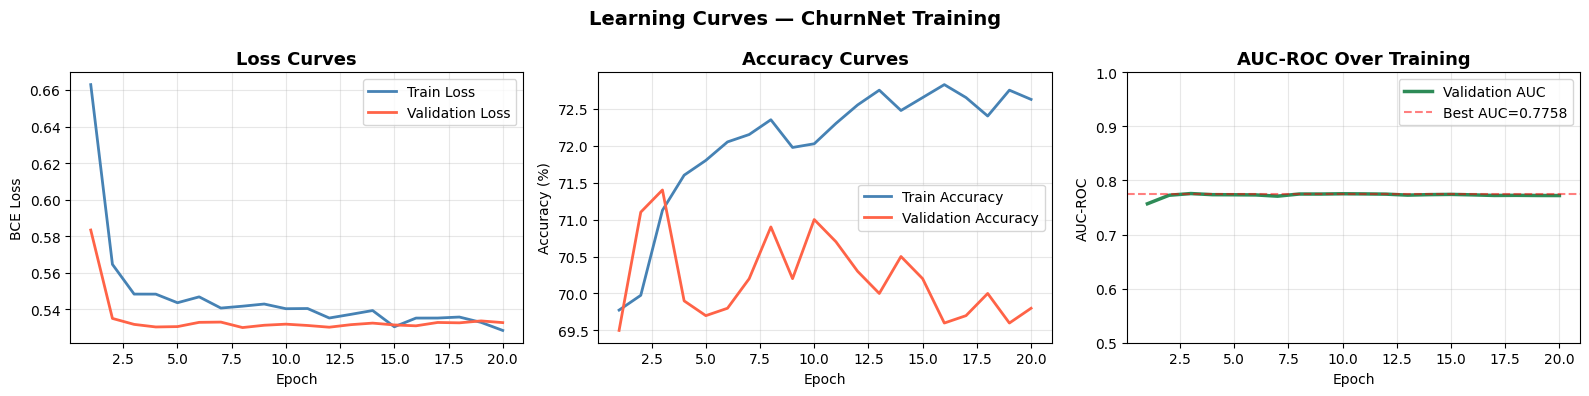

How to read learning curves:
  Both losses decreasing together  → model is learning normally
  Train loss still drops, val loss rises → OVERFITTING (too complex for data)
  Both losses barely move → UNDERFITTING (model too simple or LR too low)
  Val loss very noisy → batch size too small or LR too high


In [11]:
# ── Plot Learning Curves ─────────────────────────────────────────────
# Learning curves are how you diagnose what's happening during training

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_ran, history['train_loss'], 'steelblue', lw=2, label='Train Loss')
axes[0].plot(epochs_ran, history['val_loss'],   'tomato',    lw=2, label='Validation Loss')
axes[0].set_title('Loss Curves', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_ran, [v*100 for v in history['train_acc']], 'steelblue', lw=2, label='Train Accuracy')
axes[1].plot(epochs_ran, [v*100 for v in history['val_acc']],   'tomato',    lw=2, label='Validation Accuracy')
axes[1].set_title('Accuracy Curves', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC over time
axes[2].plot(epochs_ran, history['val_auc'], 'seagreen', lw=2.5, label='Validation AUC')
axes[2].set_title('AUC-ROC Over Training', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC-ROC')
axes[2].set_ylim(0.5, 1.0)
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].axhline(y=max(history['val_auc']), color='red', linestyle='--', alpha=0.5,
                label=f'Best AUC={max(history["val_auc"]):.4f}')
axes[2].legend()

plt.suptitle('Learning Curves — ChurnNet Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('How to read learning curves:')
print('  Both losses decreasing together  → model is learning normally')
print('  Train loss still drops, val loss rises → OVERFITTING (too complex for data)')
print('  Both losses barely move → UNDERFITTING (model too simple or LR too low)')
print('  Val loss very noisy → batch size too small or LR too high')

In [12]:
# ── Final Evaluation on Test Set ─────────────────────────────────────
_, nn_acc, nn_auc, nn_preds, nn_probs, nn_labels = evaluate(model, test_loader, criterion)

print('=== ChurnNet Final Test Results ===')
print(f'  Accuracy: {nn_acc*100:.2f}%')
print(f'  AUC-ROC:  {nn_auc:.4f}')
print()
print(classification_report(nn_labels, nn_preds, target_names=['Retained', 'Churned']))

=== ChurnNet Final Test Results ===
  Accuracy: 70.90%
  AUC-ROC:  0.7750

              precision    recall  f1-score   support

    Retained       0.76      0.80      0.78       649
     Churned       0.59      0.54      0.57       351

    accuracy                           0.71      1000
   macro avg       0.68      0.67      0.67      1000
weighted avg       0.70      0.71      0.71      1000



---

# ⚖️ STEP 5: Head-to-Head Comparison — NN vs Module 1 Models

In [13]:
from sklearn.metrics import f1_score, recall_score, precision_score

# ── Retrain Module 1 models for fair comparison ───────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=10,
                                   n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ── Compile Results ───────────────────────────────────────────────────
all_results = {
    'Logistic Regression': (lr_preds, lr_probs, y_test.values),
    'Random Forest':       (rf_preds, rf_probs, y_test.values),
    'Neural Network':      (nn_preds, nn_probs, nn_labels),
}

print('=' * 80)
print(f'{"Model":<22} {"Accuracy":>10} {"AUC":>8} {"Precision":>11} {"Recall":>9} {"F1":>7}')
print('-' * 80)
for name, (preds, probs, labels) in all_results.items():
    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs)
    p   = precision_score(labels, preds)
    r   = recall_score(labels, preds)
    f1  = f1_score(labels, preds)
    print(f'{name:<22} {acc*100:>9.2f}% {auc:>8.4f} {p*100:>10.2f}% {r*100:>8.2f}% {f1:>7.4f}')
print('=' * 80)
print('(Precision/Recall/F1 are for the Churned class)')

Model                    Accuracy      AUC   Precision    Recall      F1
--------------------------------------------------------------------------------
Logistic Regression        71.60%   0.7873      61.84%    49.86%  0.5521
Random Forest              71.00%   0.7724      60.48%    50.14%  0.5483
Neural Network             70.90%   0.7750      59.38%    54.13%  0.5663
(Precision/Recall/F1 are for the Churned class)


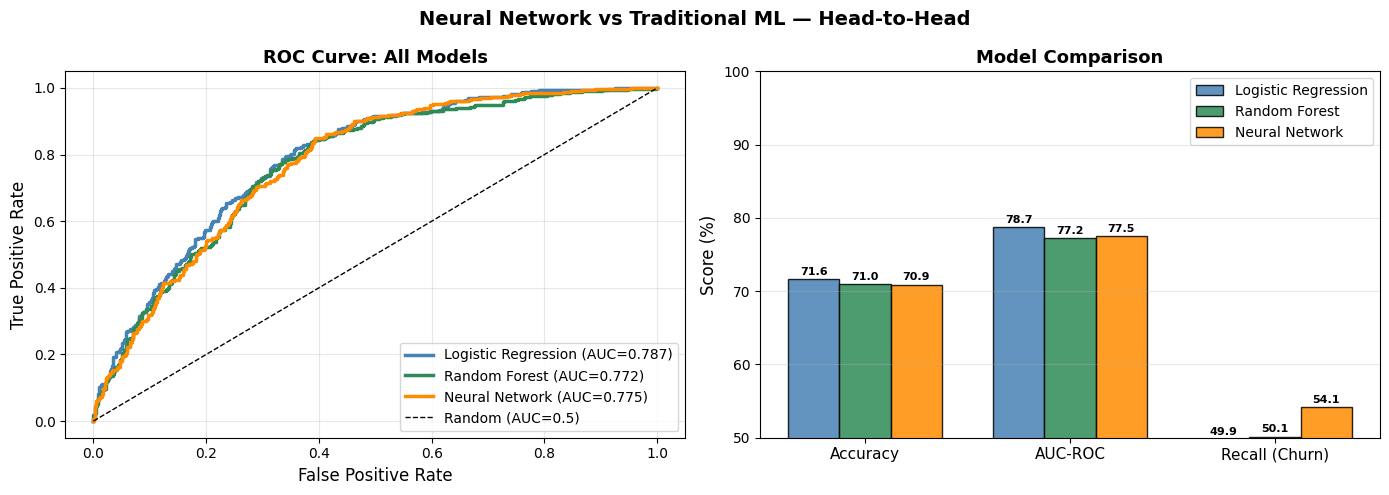

In [14]:
# ── Visual comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
colors_map = {'Logistic Regression': 'steelblue', 'Random Forest': 'seagreen', 'Neural Network': 'darkorange'}
for name, (preds, probs, labels) in all_results.items():
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, lw=2.5, color=colors_map[name], label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve: All Models', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

# Bar chart comparison
metrics = ['Accuracy', 'AUC-ROC', 'Recall (Churn)']
vals = {}
for name, (preds, probs, labels) in all_results.items():
    vals[name] = [
        accuracy_score(labels, preds)*100,
        roc_auc_score(labels, probs)*100,
        recall_score(labels, preds)*100
    ]

x = np.arange(len(metrics))
width = 0.25
for i, (name, v) in enumerate(vals.items()):
    bars = axes[1].bar(x + i*width, v, width, label=name, color=list(colors_map.values())[i],
                       alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, v):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].set_ylabel('Score (%)', fontsize=12)
axes[1].set_title('Model Comparison', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_ylim(50, 100)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Neural Network vs Traditional ML — Head-to-Head', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 What the Comparison Tells Us

On **tabular structured data** (like our churn dataset), the improvement from Neural Network vs. Random Forest is often small or negligible. This is completely expected and normal.

**Why Random Forest often wins on tabular data:**
- Tabular data has few features with clear patterns — trees handle this natively
- Neural networks need a lot of data to shine (our 5K dataset is small)
- RF is easier to tune and less sensitive to hyperparameters

**When Neural Networks dominate — the real use cases:**

| Data Type | Example | Why NN? |
|---|---|---|
| **Images** | Defect detection, face recognition | Billions of pixels — too many for trees |
| **Text** | Sentiment, classification, summarization | Sequential, context-dependent |
| **Audio** | Speech recognition | Temporal patterns |
| **Large tabular** | 100M+ rows, 1000+ features | Scale where NNs shine |
| **Multi-modal** | Image + text + metadata | Can fuse different input types |

> **The real point of learning NNs is not to beat RF on churn data.** It's to understand the foundation that powers everything from image recognition to ChatGPT.

---

# 🔬 STEP 6: Experiment — Impact of Architecture Choices

Training with Dropout (regularized)...


Training without Dropout (no regularization)...


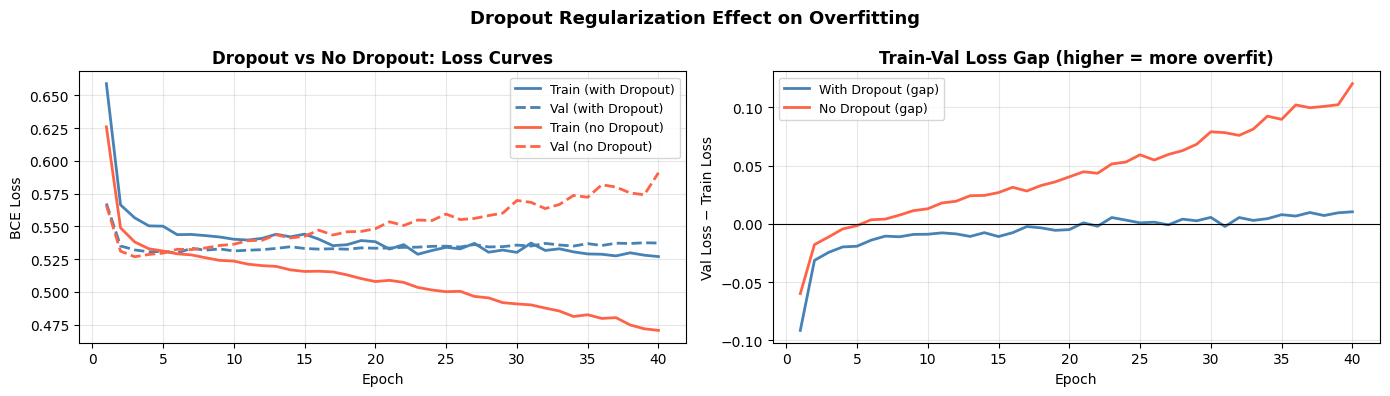

Final train-val gap WITH Dropout:    0.0103
Final train-val gap WITHOUT Dropout: 0.1203
Smaller gap = less overfitting = Dropout is working!


In [15]:
# ── Experiment: What happens without Dropout? (Overfitting demo) ──────

class ChurnNetNoDrop(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 16),         nn.ReLU(),
            nn.Linear(16, 1),          nn.Sigmoid()
        )
    def forward(self, x): return self.network(x)


def quick_train(model_class, epochs=40, **kwargs):
    m = model_class(input_size, **kwargs).to(device)
    opt = optim.Adam(m.parameters(), lr=0.001)
    crit = nn.BCELoss()
    train_losses, val_losses = [], []
    for _ in range(epochs):
        tl = train_one_epoch(m, train_loader, crit, opt)
        vl, _, _, _, _, _ = evaluate(m, test_loader, crit)
        train_losses.append(tl)
        val_losses.append(vl)
    return train_losses, val_losses


print('Training with Dropout (regularized)...')
tl_drop,   vl_drop   = quick_train(ChurnNet, epochs=40, dropout_rate=0.3)
print('Training without Dropout (no regularization)...')
tl_nodrop, vl_nodrop = quick_train(ChurnNetNoDrop, epochs=40)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, 41)

axes[0].plot(ep, tl_drop, 'steelblue', lw=2, label='Train (with Dropout)')
axes[0].plot(ep, vl_drop, 'steelblue', lw=2, linestyle='--', label='Val (with Dropout)')
axes[0].plot(ep, tl_nodrop, 'tomato', lw=2, label='Train (no Dropout)')
axes[0].plot(ep, vl_nodrop, 'tomato', lw=2, linestyle='--', label='Val (no Dropout)')
axes[0].set_title('Dropout vs No Dropout: Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Gap between train and val loss = overfitting indicator
gap_drop   = [v-t for t,v in zip(tl_drop,   vl_drop)]
gap_nodrop = [v-t for t,v in zip(tl_nodrop, vl_nodrop)]
axes[1].plot(ep, gap_drop,   'steelblue', lw=2, label='With Dropout (gap)')
axes[1].plot(ep, gap_nodrop, 'tomato',    lw=2, label='No Dropout (gap)')
axes[1].axhline(0, color='black', linestyle='-', lw=0.8)
axes[1].set_title('Train-Val Loss Gap (higher = more overfit)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss − Train Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Dropout Regularization Effect on Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dropout_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

final_gap_drop   = vl_drop[-1]   - tl_drop[-1]
final_gap_nodrop = vl_nodrop[-1] - tl_nodrop[-1]
print(f'Final train-val gap WITH Dropout:    {final_gap_drop:.4f}')
print(f'Final train-val gap WITHOUT Dropout: {final_gap_nodrop:.4f}')
print('Smaller gap = less overfitting = Dropout is working!')

---

# 💾 STEP 7: Saving and Loading Models

In production, you train a model once and save it. Then you load it for predictions without retraining.

In [16]:
# ── Save the trained model ────────────────────────────────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {'input_size': input_size, 'dropout_rate': 0.3},
    'val_auc': nn_auc,
    'scaler': scaler,
    'feature_names': list(X.columns)
}, 'churn_nn_model.pt')
print('Model saved to churn_nn_model.pt')

# ── Load and use the model ────────────────────────────────────────────
checkpoint = torch.load('churn_nn_model.pt', map_location='cpu')
loaded_model = ChurnNet(**checkpoint['model_config'])
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print(f"Loaded model with saved AUC: {checkpoint['val_auc']:.4f}")
print(f"Features expected: {checkpoint['feature_names']}")
print()

# ── Predict on a new customer ────────────────────────────────────────
# This simulates what a REST API endpoint would do
new_customer_raw = pd.DataFrame([{
    'tenure_months': 3, 'monthly_charges': 98, 'total_charges': 294,
    'num_support_calls': 6, 'num_service_outages': 2, 'age': 28,
    'has_streaming': 1, 'has_security_addon': 0,
    'contract_type_Month-to-Month': 1, 'contract_type_One-Year': 0, 'contract_type_Two-Year': 0,
    'payment_method_Bank Transfer': 0, 'payment_method_Credit Card': 0,
    'payment_method_Electronic Check': 1, 'payment_method_Mailed Check': 0
}])[checkpoint['feature_names']]

scaled = checkpoint['scaler'].transform(new_customer_raw)
tensor_input = torch.tensor(scaled, dtype=torch.float32)

with torch.no_grad():
    churn_prob_nn = loaded_model(tensor_input).item()

risk = 'HIGH RISK 🔴' if churn_prob_nn > 0.6 else 'MEDIUM RISK 🟡' if churn_prob_nn > 0.35 else 'LOW RISK 🟢'
print(f'New customer churn probability: {churn_prob_nn:.1%} → {risk}')
print('This is exactly what a production REST API endpoint does — load model, preprocess, predict.')

Model saved to churn_nn_model.pt
Loaded model with saved AUC: 0.7750
Features expected: ['tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'num_service_outages', 'age', 'has_streaming', 'has_security_addon', 'contract_type_Month-to-Month', 'contract_type_One-Year', 'contract_type_Two-Year', 'payment_method_Bank Transfer', 'payment_method_Credit Card', 'payment_method_Electronic Check', 'payment_method_Mailed Check']

New customer churn probability: 72.3% → HIGH RISK 🔴
This is exactly what a production REST API endpoint does — load model, preprocess, predict.


---

# 📊 STEP 8: When to Use Deep Learning vs Traditional ML

This is one of the most important judgment calls in enterprise ML.

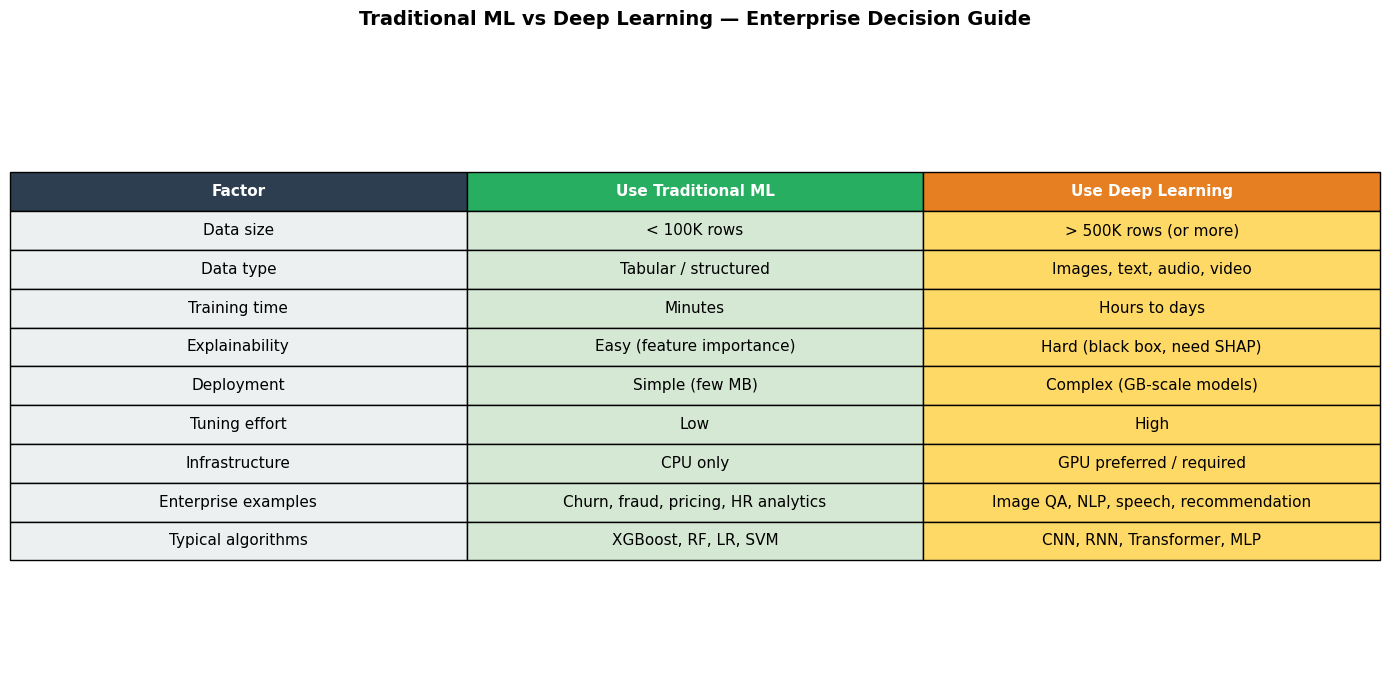

In [17]:
# ── Decision Guide Visualisation ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

table_data = [
    ['Factor', 'Use Traditional ML', 'Use Deep Learning'],
    ['Data size', '< 100K rows', '> 500K rows (or more)'],
    ['Data type', 'Tabular / structured', 'Images, text, audio, video'],
    ['Training time', 'Minutes', 'Hours to days'],
    ['Explainability', 'Easy (feature importance)', 'Hard (black box, need SHAP)'],
    ['Deployment', 'Simple (few MB)', 'Complex (GB-scale models)'],
    ['Tuning effort', 'Low', 'High'],
    ['Infrastructure', 'CPU only', 'GPU preferred / required'],
    ['Enterprise examples', 'Churn, fraud, pricing, HR analytics', 'Image QA, NLP, speech, recommendation'],
    ['Typical algorithms', 'XGBoost, RF, LR, SVM', 'CNN, RNN, Transformer, MLP'],
]

colors = [['#2c3e50','#27ae60','#e67e22']] + \
         [['#ecf0f1', '#d5e8d4', '#ffd966'] for _ in range(len(table_data)-1)]

table = ax.table(
    cellText=table_data,
    cellLoc='center',
    loc='center',
    cellColours=colors
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

# Header row bold
for j in range(3):
    table[0, j].set_text_props(fontweight='bold', color='white')

ax.set_title('Traditional ML vs Deep Learning — Enterprise Decision Guide',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('ml_vs_dl_guide.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 🏁 SUMMARY — What You Learned in Module 2

## Core Deep Learning Concepts

### The Building Blocks
- ✅ **Neuron**: weighted sum of inputs + bias → activation function → output
- ✅ **Activation functions**: ReLU (hidden layers), Sigmoid (binary output)
- ✅ **Layer**: a group of neurons processing data together
- ✅ **Network depth**: more layers = can learn more complex patterns

### The Learning Process
- ✅ **Forward pass**: data flows input → hidden → output, producing a prediction
- ✅ **Loss function**: measures how wrong the prediction is (BCE for classification)
- ✅ **Backpropagation**: computes how much each weight caused the error
- ✅ **Gradient descent**: adjusts weights to reduce the loss
- ✅ **Learning rate**: step size of weight adjustments
- ✅ **Epochs & batches**: how training iterates over data

### Preventing Overfitting
- ✅ **Dropout**: randomly disables neurons during training
- ✅ **Batch Normalisation**: stabilises training, acts as mild regularization
- ✅ **Early stopping**: stops training when val loss stops improving

### PyTorch
- ✅ Tensors and autograd
- ✅ `nn.Module` model definition
- ✅ `DataLoader` for batched training
- ✅ The standard training loop
- ✅ Saving and loading models

---

## 🎓 Interview Answers You Can Now Give

**Q: What is backpropagation?**  
A: Backpropagation uses the chain rule of calculus to compute how much each weight in the network contributed to the prediction error. It works backwards from the output layer to the input layer. PyTorch handles this automatically via autograd — you just call `.backward()` on the loss.

**Q: Why use ReLU instead of Sigmoid in hidden layers?**  
A: Sigmoid saturates at both ends, producing near-zero gradients for very large or very small inputs. This causes the vanishing gradient problem — early layers stop learning because their gradients become tiny. ReLU has a constant gradient of 1 for positive inputs, avoiding this. It's also computationally faster.

**Q: What is overfitting and how do you prevent it in a neural network?**  
A: Overfitting is when the model memorises training data, including noise, and fails to generalise to new data. Prevention: Dropout (randomly disables neurons), Batch Normalisation (stabilises activations), Early Stopping (stop before the model memorises), Weight Decay / L2 Regularization, more training data, or a simpler architecture.

**Q: When would you use a neural network vs. Random Forest?**  
A: Random Forest is often better for structured tabular data, especially under 100K rows, due to its robustness, interpretability, and low tuning needs. Neural networks are essential for unstructured data — images, text, audio — and for very large datasets where they can leverage scale. For tabular enterprise data, I'd start with XGBoost/RF and only add the complexity of a neural network if there's a clear reason.

---

## 🚀 What's Next — Module 3 Preview

**Module 3: Fine-Tuning NLP Models (BERT / DistilBERT)**

This is where GenAI meets traditional ML. You'll learn:
- What transfer learning is and why it changed everything in AI
- How BERT was pre-trained on billions of words and what it learned
- How to take a pre-trained BERT and fine-tune it on your own task in < 1 hour
- Enterprise use case: Customer support ticket classification
- The bridge from this module: we're still using the same training loop — just starting from pre-trained weights instead of random ones

The fundamental shift: instead of training a network from scratch (which needs millions of examples), we *reuse* a model that already understands language and just teach it our specific task. This is the foundation of all modern LLM fine-tuning.

---

## 📚 Further Reading

- **3Blue1Brown Neural Networks** (YouTube): Best visual explanation of backprop ever made
- **PyTorch Official Tutorials**: https://pytorch.org/tutorials/
- **fast.ai Deep Learning Course**: Free, practical, excellent
- **Andrej Karpathy's nn-zero-to-hero**: Build GPT from scratch — directly builds on this module

---

*Module 2 of 6 — Fine-Tuning & ML Fundamentals Series*  
*Next: Module 3 — Fine-Tuning Pre-trained NLP Models (HuggingFace + BERT)*